In [2]:
# ============================================================
# 0. 환경설정 및 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# 한글 폰트 설정 (Windows 기준, 필요시 폰트명 조정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [3]:
# ============================================================
# 1. 데이터 불러오기
# ============================================================
df = pd.read_csv("../marketing_campaign.csv", sep=";")
 
print(f"원본 shape: {df.shape}")
df.head()

원본 shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [3]:
# ============================================================
# 2. 데이터 기본 정보 파악
# ============================================================
print("\n=== info() ===")
df.info()
 
print("\n=== 수치형 변수 기술통계 ===")
print(df.describe())
 
print("\n=== 범주형 변수 고유값 확인 ===")
for col in ["Education", "Marital_Status"]:
    print(f"\n[{col}]")
    print(df[col].value_counts())


=== info() ===
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-nul

In [4]:
# ============================================================
# 3. 결측치 확인
# ============================================================
print("\n=== 결측치 확인 ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nIncome 결측 비율: {df['Income'].isnull().mean()*100:.2f}%")


=== 결측치 확인 ===
Income    24
dtype: int64

Income 결측 비율: 1.07%



=== Year_Birth 분포 ===
count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64
239     1893
339     1899
192     1900
1950    1940
424     1941
1923    1943
415     1943
894     1943
39      1943
1150    1943
Name: Year_Birth, dtype: int64

=== Income 분포 ===
count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
Name: Income, dtype: float64


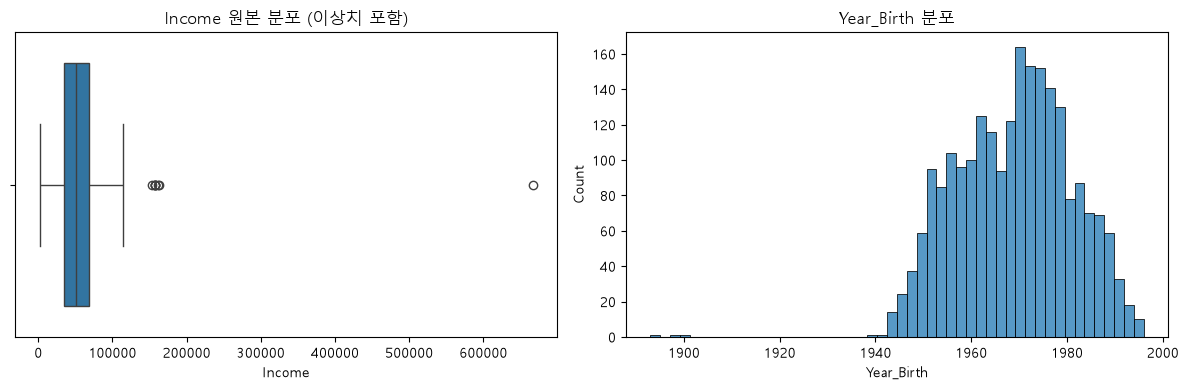

In [5]:
# ============================================================
# 4. 이상치 확인 
# ============================================================
 
# 4-1. Year_Birth 이상치 확인
print("\n=== Year_Birth 분포 ===")
print(df["Year_Birth"].describe())
print(df["Year_Birth"].sort_values().head(10))  # 너무 오래된 값들 확인
 
# 4-2. Income 이상치 확인
print("\n=== Income 분포 ===")
print(df["Income"].describe())
print(df["Income"].sort_values(ascending=False).head(10))  # 상위 이상치 확인
 
# Income 분포 시각화 (박스플롯으로 이상치 눈으로 확인)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Income"], ax=axes[0])
axes[0].set_title("Income 원본 분포 (이상치 포함)")
sns.histplot(df["Year_Birth"], bins=50, ax=axes[1])
axes[1].set_title("Year_Birth 분포")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 5. 전처리 
# ============================================================
df_clean = df.copy()
 
# ------------------------------------------------------------
# 5-1. Year_Birth -> 1940년대 이후만 남기고 Age로 변환 (2014년 기준)
# ------------------------------------------------------------
# 이 데이터는 수집 시점이 2014년경으로 알려져 있어 기준 연도로 사용
REFERENCE_YEAR = 2014
 
before_n = len(df_clean)
df_clean = df_clean[df_clean["Year_Birth"] >= 1940].copy()
print(f"\nYear_Birth < 1940 이상치 제거: {before_n - len(df_clean)}건 제거됨")
 
df_clean["Age"] = REFERENCE_YEAR - df_clean["Year_Birth"]
df_clean = df_clean.drop(columns=["Year_Birth"])
 
print(df_clean["Age"].describe())
 


Year_Birth < 1940 이상치 제거: 3건 제거됨
count    2237.000000
mean       45.098346
std        11.701917
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64


In [7]:
# ------------------------------------------------------------
# 5-2. Education -> "2n Cycle"을 "Master"로 통일
# ------------------------------------------------------------
print("\n통일 전 Education 값:", df_clean["Education"].unique())
df_clean["Education"] = df_clean["Education"].replace("2n Cycle", "Master")
print("통일 후 Education 값:", df_clean["Education"].unique())


통일 전 Education 값: <ArrowStringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str
통일 후 Education 값: <ArrowStringArray>
['Graduation', 'PhD', 'Master', 'Basic']
Length: 4, dtype: str


In [8]:
# ------------------------------------------------------------
# 5-3. Marital_Status -> Alone, Absurd, YOLO를 Single로 통일
# ------------------------------------------------------------
print("\n통일 전 Marital_Status 값:", df_clean["Marital_Status"].unique())
df_clean["Marital_Status"] = df_clean["Marital_Status"].replace(
    ["Alone", "Absurd", "YOLO"], "Single"
)
print("통일 후 Marital_Status 값:", df_clean["Marital_Status"].unique())


통일 전 Marital_Status 값: <ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd', 'YOLO']
Length: 8, dtype: str
통일 후 Marital_Status 값: <ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow']
Length: 5, dtype: str


In [9]:
# ------------------------------------------------------------
# 5-4. Income -> 결측치 및 이상치(666666) 중앙값으로 대체
#      단, 7500 중복 12건은 유지 (이미 전처리됐거나 디폴트 값일 가능성 -> 주석 처리)
# ------------------------------------------------------------
# 결측 여부를 별도 플래그로 남겨서 나중에 결측이었던 케이스가 분석 결과에 영향을 주는지 추적할 수 있게 함
df_clean["Income_was_missing"] = df_clean["Income"].isnull().astype(int)
 
# 666666은 입력 오류로 보이는 명백한 이상치 (소득 범위를 벗어나는 값) -> 결측치와 동일하게 취급해 중앙값으로 대체
df_clean["Income"] = df_clean["Income"].replace(666666, np.nan)

income_median = df_clean["Income"].median()
df_clean["Income"] = df_clean["Income"].fillna(income_median)
print(f"Income 결측/이상치 대체값(중앙값): {income_median}")

# 참고: Income == 7500인 값이 12건 중복되어 있음.
#   -> 이는 이상치라기보다 "설문/시스템의 디폴트 값" 혹은 "이미 한 번 전처리(예: 결측 대체)가 이루어진 값"일 가능성이 있어 
#      임의로 제거하지 않고 그대로 유지함
print("Income == 7500 중복 건수:", (df_clean["Income"] == 7500).sum())

Income 결측/이상치 대체값(중앙값): 51371.0
Income == 7500 중복 건수: 12


In [10]:
# ------------------------------------------------------------
# 5-5. Dt_Customer -> datetime으로 변환
# ------------------------------------------------------------
df_clean["Dt_Customer"] = pd.to_datetime(df_clean["Dt_Customer"], format="%Y-%m-%d")
print("\nDt_Customer 변환 후 dtype:", df_clean["Dt_Customer"].dtype)
print(df_clean["Dt_Customer"].head())


Dt_Customer 변환 후 dtype: datetime64[us]
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]


In [11]:
# ------------------------------------------------------------
# 5-6. Kidhome, Teenhome -> Children 파생변수 생성
# ------------------------------------------------------------
df_clean["Children"] = df_clean["Kidhome"] + df_clean["Teenhome"]
print("\nChildren 값 분포:")
print(df_clean["Children"].value_counts().sort_index())


Children 값 분포:
Children
0     637
1    1126
2     421
3      53
Name: count, dtype: int64


In [12]:
# ------------------------------------------------------------
# 5-7. 완전 중복 행 제거 (ID 제외 모든 컬럼 동일)
# ------------------------------------------------------------
cols_except_id = [c for c in df_clean.columns if c != "ID"]
dup_full = df_clean.duplicated(subset=cols_except_id, keep=False)
print(f"\n완전 중복(ID 제외) 발견: {dup_full.sum()}건")
 
before_n = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=cols_except_id, keep="first")
print(f"완전 중복 제거: {before_n - len(df_clean)}건 제거됨")


완전 중복(ID 제외) 발견: 362건
완전 중복 제거: 184건 제거됨


In [13]:
# ------------------------------------------------------------
# 5-8. Response만 다른 40건 처리 -> Response==1 행만 남기고 0인 행 삭제
#      (ID, Response 제외 나머지 전부 동일한 그룹)
# ------------------------------------------------------------
cols_except_id_response = [c for c in df_clean.columns if c not in ["ID", "Response"]]
 
# Response가 서로 다르게 찍힌 그룹 식별
conflict_group_sizes = df_clean.groupby(cols_except_id_response)["Response"].transform("nunique")
conflict_mask = conflict_group_sizes > 1
print(f"\nResponse만 다른 레코드: {conflict_mask.sum()}건")
 
# 그룹 내에서 Response==0인 행만 제거 (Response==1인 행 유지)
rows_to_drop = df_clean[conflict_mask & (df_clean["Response"] == 0)].index
before_n = len(df_clean)
df_clean = df_clean.drop(index=rows_to_drop)
print(f"Response=0 행 제거: {before_n - len(df_clean)}건 제거됨")


Response만 다른 레코드: 38건
Response=0 행 제거: 19건 제거됨


In [14]:
# ------------------------------------------------------------
# 5-9. 불필요한 컬럼 제거: Z_CostContact, Z_Revenue
# ------------------------------------------------------------
drop_cols = [c for c in ["Z_CostContact", "Z_Revenue"] if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)
print(f"\n제거된 컬럼: {drop_cols}")


제거된 컬럼: ['Z_CostContact', 'Z_Revenue']


In [15]:
# ------------------------------------------------------------
# 5-10. AnyAccepted 파생변수 생성
#       AcceptedCmp1~5 중 하나라도 수락했으면 1, 아니면 0
# ------------------------------------------------------------
cmp_cols = [f"AcceptedCmp{i}" for i in range(1, 6)]
df_clean["AnyAccepted"] = (df_clean[cmp_cols].sum(axis=1) > 0).astype(int)
print("\nAnyAccepted 분포:")
print(df_clean["AnyAccepted"].value_counts(normalize=True))
 


AnyAccepted 분포:
AnyAccepted
0    0.792035
1    0.207965
Name: proportion, dtype: float64


In [16]:
# ============================================================
# 6. 전처리 후 최종 점검
# ============================================================
print(f"\n=== 최종 shape: {df_clean.shape} (원본 {df.shape}) ===")
print("\n=== 최종 결측치 확인 ===")
print(df_clean.isnull().sum().sum(), "건")
 
print("\n=== 최종 컬럼 목록 ===")
print(df_clean.columns.tolist())
 
print("\n=== 최종 데이터 미리보기 ===")
df_clean.head()  


=== 최종 shape: (2034, 30) (원본 (2240, 29)) ===

=== 최종 결측치 확인 ===
0 건

=== 최종 컬럼 목록 ===
['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Income_was_missing', 'Children', 'AnyAccepted']

=== 최종 데이터 미리보기 ===


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Income_was_missing,Children,AnyAccepted
0,5524,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,0,0,0
1,2174,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,0,2,0
2,4141,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,0,0,0
3,6182,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,0,1,0
4,5324,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,0,1,0


In [17]:
# ============================================================
# 7. 전처리 완료 데이터 저장
# ============================================================
df_clean.to_csv("marketing_campaign_cleaned.csv", index=False)
print("\n전처리 완료 파일 저장: marketing_campaign_cleaned.csv")  


전처리 완료 파일 저장: marketing_campaign_cleaned.csv
